# Decision Tree Classifier

Build a model to predict the drug to be prescribed to a patient based on their medical results.

Step 1: Import data

In [2]:
import pandas as pd
path = r"C:\Users\Khushi Kanade\OneDrive\Desktop\ML\drug200.csv"
df = pd.read_csv(path)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Step 2: Data quality checks

In [3]:
df.shape

(200, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#handle duplicates for future cases
df = df.drop_duplicates()

In [7]:
#check missing values
df.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Step 3: Seperate X and Y features
X : all features except drug
Y : drug

In [8]:
X = df.drop(columns =['Drug'])
Y = df[['Drug']]

In [9]:
X.head()


,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


In [10]:
Y.head()

,Drug
0,DrugY
1,drugC
2,drugC
3,drugX
4,DrugY


Step 4: Feature Engineering

In [11]:
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include = 'object').columns)
con = list(X.select_dtypes(include = 'number'))

#numerical pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy ='mean'),
    StandardScaler()
)

#categorical pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'),
    OneHotEncoder(handle_unknown ='ignore',sparse_output=False)

)

pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',num_pipe,con)
]).set_output(transform = 'pandas')

X_pre = pre.fit_transform(X)
X_pre.head()

,cat__Sex_F,cat__Sex_M,cat__BP_HIGH,cat__BP_LOW,cat__BP_NORMAL,cat__Cholesterol_HIGH,cat__Cholesterol_NORMAL,con__Age,con__Na_to_K
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.291591,1.286522
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.162699,-0.415145
2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.162699,-0.828558
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.988614,-1.149963
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.011034,0.271794


Step 5 : Model prep and building

In [13]:
#splitting train and test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_pre,Y,train_size=0.7,random_state=21)

In [14]:
x_train.shape

(140, 9)

In [15]:
y_train.shape

(140, 1)

In [16]:
x_test.shape

(60, 9)

In [17]:
y_test.shape

(60, 1)

In [18]:
#Model building
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 5,
    min_samples_split=5,
    min_samples_leaf=3
)

model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
#model score on training data
model.score(x_train,y_train)

1.0

In [20]:
#model score on testing data
model.score(x_test,y_test)

0.9666666666666667

Hyperparameter Tuning

In [21]:
hyperparams = {
   'criterion': ['gini','entropy'],
  'max_depth' : [3,4,5,6,7],
  'min_samples_leaf' : [1,2,3,5,10],
  'min_samples_split' : [3,5,10]
}

In [22]:
from sklearn.model_selection import RandomizedSearchCV
basemodel = DecisionTreeClassifier()
rscv = RandomizedSearchCV(estimator = basemodel,param_distributions =hyperparams,cv=3,scoring='f1_macro')
rscv.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [3, 5, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


Step 6: Model Evaluation

In [23]:
rscv.best_params_

{'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 4,
 'criterion': 'entropy'}

In [24]:
rscv.best_score_

np.float64(0.9957829457364341)

In [25]:
best_dtc = rscv.best_estimator_

In [26]:
best_dtc.score(x_train,y_train)

1.0

In [27]:
best_dtc.score(x_test,y_test)

0.9666666666666667

Confusion Matrix and Classification Report

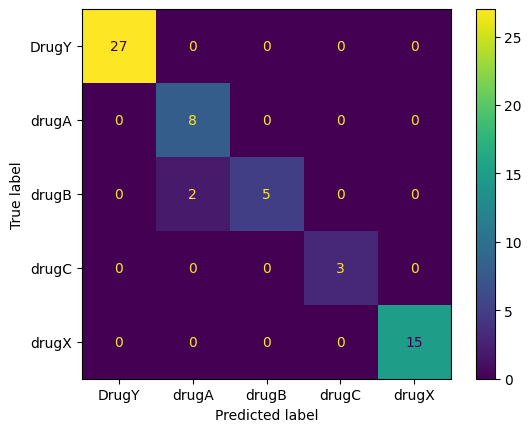

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_dtc,x_test,y_test)

In [29]:
from sklearn.metrics import classification_report
y_preds = best_dtc.predict(x_test)
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        27
       drugA       0.80      1.00      0.89         8
       drugB       1.00      0.71      0.83         7
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        15

    accuracy                           0.97        60
   macro avg       0.96      0.94      0.94        60
weighted avg       0.97      0.97      0.97        60



Save the model and preprocessor pipeline

In [30]:
import joblib
joblib.dump(pre,'pre.joblib')
joblib.dump(best_dtc,'dtcmodel.joblib')

['dtcmodel.joblib']

Importing model and making new predictions

In [31]:
pre_test = joblib.load('pre.joblib')
dtcmodel_test = joblib.load('dtcmodel.joblib')

In [33]:
df.shape

(200, 6)

In [35]:
df_new = pd.read_csv(r"C:\Users\Khushi Kanade\OneDrive\Desktop\ML\DrugTest.csv")
df_new.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,22.0,F,HIGH,NORMAL,22.818
1,15.0,M,HIGH,NORMAL,17.206
2,67.0,M,NORMAL,NORMAL,9.514
3,68.0,M,NaN,HIGH,11.009
4,70.0,F,NORMAL,HIGH,NaN


In [36]:
# prepare the data using pipeline
df_new_pre = pre.transform(df_new)
df_new_pre.head()

,cat__Sex_F,cat__Sex_M,cat__BP_HIGH,cat__BP_LOW,cat__BP_NORMAL,cat__Cholesterol_HIGH,cat__Cholesterol_NORMAL,con__Age,con__Na_to_K
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.352186,0.934448
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,-1.776354,0.155639
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.374607,-0.911824
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.435202,-0.704354
4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.556393,0.000000


In [39]:
preds = best_dtc.predict(df_new_pre) 
preds

array(['DrugY', 'DrugY', 'drugX', 'drugB', 'DrugY', 'DrugY', 'DrugY',
       'drugA', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugC', 'drugC',
       'DrugY', 'DrugY', 'DrugY', 'drugB', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'drugX', 'drugA', 'drugB', 'drugC', 'DrugY', 'drugA',
       'drugB', 'drugA', 'DrugY', 'drugA', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'drugC', 'DrugY', 'DrugY', 'drugX', 'DrugY', 'drugX',
       'drugX', 'drugX', 'DrugY', 'drugA', 'drugX', 'drugB', 'DrugY',
       'DrugY'], dtype=object)

In [40]:
df_new['Drug_predictions'] = preds
df_new

,Age,Sex,BP,Cholesterol,Na_to_K,Drug_predictions
0,22.0,F,HIGH,NORMAL,22.818,DrugY
1,15.0,M,HIGH,NORMAL,17.206,DrugY
2,67.0,M,NORMAL,NORMAL,9.514,drugX
3,68.0,M,NaN,HIGH,11.009,drugB
4,70.0,F,NORMAL,HIGH,NaN,DrugY
5,67.0,F,NORMAL,HIGH,15.891,DrugY
6,NaN,M,NORMAL,HIGH,25.786,DrugY
7,51.0,M,HIGH,NORMAL,11.343,drugA
8,23.0,F,HIGH,HIGH,25.355,DrugY
9,35.0,M,LOW,NORMAL,9.170,drugX


In [41]:
#save the file
df_new.to_csv('DrugPredictions.csv',index=False)

In [42]:
df.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [49]:
df['Cholesterol'].unique()

array(['HIGH', 'NORMAL'], dtype=object)